# Task 2 — Alternative Clustering Family: Gaussian Mixture Model
*(includes Task 3.2 family-specific diagnostic: AIC / BIC curves)*

**Team:** Luís Serrano (60253), Tiago Fonseca (72898), Miguel Teixeira (72922)

**Inputs required (produced by `project.ipynb`):**
- `tables/final_precluster_matrix.csv` — 47-D preprocessed feature matrix

**Outputs produced:**
- `tables/gmm_aic_bic.csv` — AIC / BIC sweep
- `tables/gmm_labels.csv` — full-dataset cluster labels (best GMM)
- `tables/gmm_proba.npy` — full-dataset soft memberships
- `figures/gmm_aic_bic.png` — Task 3.2 diagnostic figure
- `tables/experiments.csv` — updated with GMM sweep rows

---

## Justification for GMM

1. **Conceptually distinct from k-means**: GMM is a probabilistic generative model that assigns **soft memberships**; k-means produces hard Voronoi-partition assignments.
2. **Compatible with the representation**: the 47-D standardised Euclidean space (StandardScaler + log1p + OHE) makes Gaussian likelihood a reasonable working assumption.
3. **Principled model selection**: AIC and BIC give a formal criterion for choosing *k*, unlike the elbow/silhouette heuristics used for k-means.

### Covariance type: `diag`

With *d* = 47 features, a `full` covariance has *d(d+1)/2* = 1 128 parameters per component (≈ 9 000 total for *k* = 8) — expensive and prone to singularity on sparse one-hot columns. `diag` reduces this to 47 variance parameters per component (≈ 380 total). `reg_covar=1e-4` adds numerical stability. `n_init=3` mitigates EM initialisation sensitivity.

## 0. Setup

In [8]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 12, 'axes.labelsize': 11})

# ── Constants ──────────────────────────────────────────────────────────────
EVAL_SEED        = 42
EVAL_N           = 20_000
K_RANGE          = [3, 4, 5, 6, 7, 8]
GMM_COV_TYPE     = 'diag'
GMM_N_INIT       = 3
GMM_MAX_ITER     = 200
GMM_REG_COVAR    = 1e-4
KMEANS_REF_K     = 8
KMEANS_REF_SEED  = 42
MIN_CLUSTER_SHARE = 0.01

# ── Path detection ─────────────────────────────────────────────────────────
_cwd = Path('.').resolve()
_tables_dir = None
for _p in [_cwd] + list(_cwd.parents):
    if (_p / 'tables' / 'experiments.csv').exists():
        _tables_dir = _p / 'tables'; break
    if (_p / 'experiments.csv').exists():
        _tables_dir = _p; break
TABLES_DIR = _tables_dir or _cwd
FIGURES_DIR = TABLES_DIR.parent / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'TABLES_DIR : {TABLES_DIR.resolve()}')
print(f'FIGURES_DIR: {FIGURES_DIR.resolve()}')

TABLES_DIR : C:\Users\tfons\OneDrive\Ambiente de Trabalho\usl_project1_72922_72898_60253\tables
FIGURES_DIR: C:\Users\tfons\OneDrive\Ambiente de Trabalho\usl_project1_72922_72898_60253\figures


## 1. Load preprocessed data

In [9]:
matrix_path = TABLES_DIR / 'final_precluster_matrix.csv'
print(f'Loading: {matrix_path.resolve()}')
t0 = time.perf_counter()
X_prepared = pd.read_csv(matrix_path).values
print(f'  Shape: {X_prepared.shape}  |  dtype: {X_prepared.dtype}')
print(f'  NaN: {np.isnan(X_prepared).sum()}  |  loaded in {time.perf_counter()-t0:.1f}s')

# Fixed eval subsample (same protocol as baseline)
rng_eval   = np.random.default_rng(EVAL_SEED)
sample_idx = rng_eval.choice(X_prepared.shape[0], size=EVAL_N, replace=False)
X_eval     = X_prepared[sample_idx]
print(f'Eval subsample: {X_eval.shape}')

Loading: C:\Users\tfons\OneDrive\Ambiente de Trabalho\usl_project1_72922_72898_60253\tables\final_precluster_matrix.csv
  Shape: (119192, 47)  |  dtype: float64
  NaN: 0  |  loaded in 0.3s
Eval subsample: (20000, 47)


## 2. GMM AIC / BIC sweep (Task 2)

In [10]:
print(f'GMM sweep k={K_RANGE} | cov={GMM_COV_TYPE!r} | n_init={GMM_N_INIT} ...')
aic_scores, bic_scores, ll_scores, sweep_times = [], [], [], []

for k in K_RANGE:
    t0 = time.perf_counter()
    gmm_k = GaussianMixture(
        n_components=k, covariance_type=GMM_COV_TYPE,
        n_init=GMM_N_INIT, max_iter=GMM_MAX_ITER,
        random_state=EVAL_SEED, reg_covar=GMM_REG_COVAR,
    )
    gmm_k.fit(X_prepared)
    elapsed = time.perf_counter() - t0
    aic = gmm_k.aic(X_prepared)
    bic = gmm_k.bic(X_prepared)
    ll  = gmm_k.score(X_prepared)
    aic_scores.append(aic)
    bic_scores.append(bic)
    ll_scores.append(ll)
    sweep_times.append(elapsed)
    print(f'  k={k} | AIC={aic:,.0f} | BIC={bic:,.0f} | LL={ll:.4f} | t={elapsed:.1f}s')

aic_bic_df = pd.DataFrame({
    'k': K_RANGE, 'aic': aic_scores, 'bic': bic_scores,
    'log_likelihood': ll_scores, 'runtime_sec': sweep_times,
})
aic_bic_df.to_csv(TABLES_DIR / 'gmm_aic_bic.csv', index=False)
display(aic_bic_df.round(2))
print('Saved: tables/gmm_aic_bic.csv')

GMM sweep k=[3, 4, 5, 6, 7, 8] | cov='diag' | n_init=3 ...
  k=3 | AIC=-7,769,133 | BIC=-7,766,381 | LL=32.5932 | t=3.5s
  k=4 | AIC=-10,096,812 | BIC=-10,093,140 | LL=42.3584 | t=2.8s
  k=5 | AIC=-11,663,727 | BIC=-11,659,135 | LL=48.9323 | t=2.6s
  k=6 | AIC=-11,545,234 | BIC=-11,539,721 | LL=48.4360 | t=3.6s
  k=7 | AIC=-11,993,621 | BIC=-11,987,188 | LL=50.3178 | t=4.9s
  k=8 | AIC=-13,320,469 | BIC=-13,313,115 | LL=55.8846 | t=8.2s


,k,aic,bic,log_likelihood,runtime_sec
0,3,-7769132.74,-7766381.21,32.59,3.51
1,4,-10096812.20,-10093140.26,42.36,2.79
2,5,-11663727.27,-11659134.93,48.93,2.63
3,6,-11545233.89,-11539721.13,48.44,3.64
4,7,-11993621.28,-11987188.12,50.32,4.90
5,8,-13320468.92,-13313115.36,55.88,8.21


Saved: tables/gmm_aic_bic.csv


## 3. Task 3.2 — AIC / BIC curves (family-specific diagnostic)

- **AIC** penalises model complexity lightly — tends to favour higher *k*.
- **BIC** penalises more strongly — preferred for model selection.
- We select *k* at the **BIC minimum** (stronger parsimony criterion).

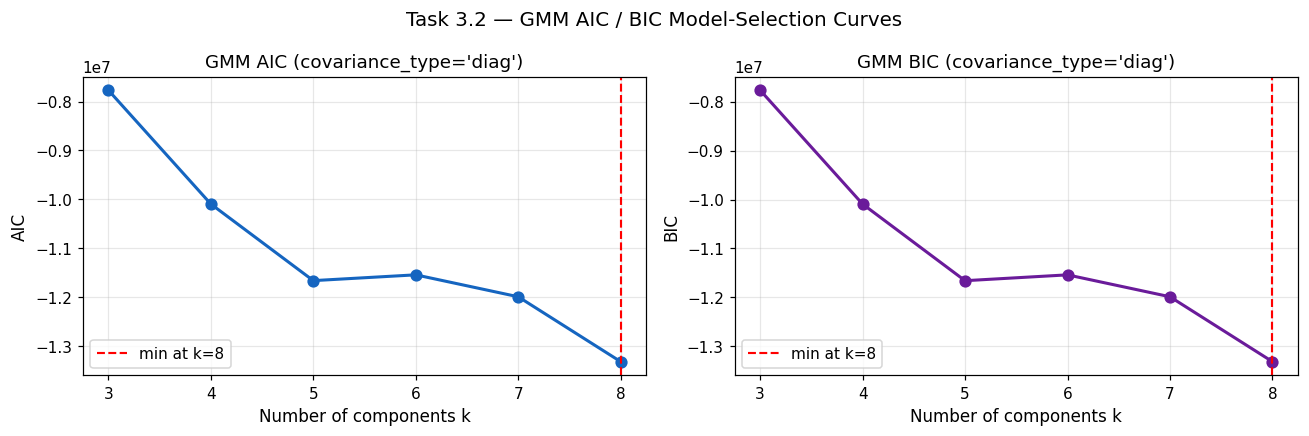

Saved: figures/gmm_aic_bic.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (metric, scores, colour) in zip(axes, [
    ('AIC', aic_scores, '#1565C0'),
    ('BIC', bic_scores, '#6A1B9A'),
]):
    best_idx = int(np.argmin(scores))
    best_k   = K_RANGE[best_idx]
    ax.plot(K_RANGE, scores, 'o-', color=colour, lw=2, ms=7)
    ax.axvline(best_k, ls='--', color='red', lw=1.4, label=f'min at k={best_k}')
    ax.set_xlabel('Number of components k')
    ax.set_ylabel(metric)
    ax.set_title(f'GMM {metric} (covariance_type={GMM_COV_TYPE!r})')
    ax.set_xticks(K_RANGE)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Task 3.2 — GMM AIC / BIC Model-Selection Curves', fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'gmm_aic_bic.png', bbox_inches='tight')
plt.show()
print('Saved: figures/gmm_aic_bic.png')

## 4. Model selection and final GMM fit

In [12]:
best_bic_k = K_RANGE[int(np.argmin(bic_scores))]
best_aic_k = K_RANGE[int(np.argmin(aic_scores))]
print(f'AIC-optimal k : {best_aic_k}')
print(f'BIC-optimal k : {best_bic_k}  <- selected')
GMM_BEST_K = best_bic_k

print(f'\nFitting final GMM k={GMM_BEST_K} (seed={EVAL_SEED}) ...')
t0 = time.perf_counter()
gmm_final = GaussianMixture(
    n_components=GMM_BEST_K, covariance_type=GMM_COV_TYPE,
    n_init=GMM_N_INIT, max_iter=GMM_MAX_ITER,
    random_state=EVAL_SEED, reg_covar=GMM_REG_COVAR,
)
gmm_final.fit(X_prepared)
gmm_labels = gmm_final.predict(X_prepared)
gmm_proba  = gmm_final.predict_proba(X_prepared)
print(f'  done in {time.perf_counter()-t0:.1f}s')

gmm_share     = pd.Series(gmm_labels).value_counts(normalize=True).sort_index()
gmm_min_share = float(gmm_share.min())
print(f'\nCluster shares (%):')
print((gmm_share * 100).round(2).to_string())
print(f'\nMin cluster share: {gmm_min_share*100:.2f}% '
      + ('OK' if gmm_min_share >= MIN_CLUSTER_SHARE else 'WARNING: below 1% guardrail'))

# Eval metrics
gmm_labels_eval = gmm_labels[sample_idx]
gmm_sil = silhouette_score(X_eval, gmm_labels_eval, metric='euclidean')
gmm_ch  = calinski_harabasz_score(X_eval, gmm_labels_eval)
gmm_db  = davies_bouldin_score(X_eval, gmm_labels_eval)
print(f'\nInternal validity (eval n={EVAL_N:,}): Sil={gmm_sil:.4f} | CH={gmm_ch:.1f} | DB={gmm_db:.4f}')

AIC-optimal k : 8
BIC-optimal k : 8  <- selected

Fitting final GMM k=8 (seed=42) ...
  done in 8.8s

Cluster shares (%):
0    23.86
1    31.97
2     4.51
3    10.26
4     1.45
5    13.03
6     5.51
7     9.41

Min cluster share: 1.45% OK

Internal validity (eval n=20,000): Sil=0.0358 | CH=911.7 | DB=3.0756


## 5. Save outputs for Task 3

In [13]:
# Labels CSV (integer cluster per observation)
pd.DataFrame({'gmm_label': gmm_labels}).to_csv(TABLES_DIR / 'gmm_labels.csv', index=False)
print(f'Saved: tables/gmm_labels.csv  shape=({len(gmm_labels)},)')

# Soft membership probabilities (npy — compact)
np.save(TABLES_DIR / 'gmm_proba.npy', gmm_proba)
print(f'Saved: tables/gmm_proba.npy  shape={gmm_proba.shape}')

# Best k for downstream notebooks
(TABLES_DIR / 'gmm_best_k.txt').write_text(str(GMM_BEST_K), encoding='utf-8')
print(f'Saved: tables/gmm_best_k.txt  (k={GMM_BEST_K})')

Saved: tables/gmm_labels.csv  shape=(119192,)
Saved: tables/gmm_proba.npy  shape=(119192, 8)
Saved: tables/gmm_best_k.txt  (k=8)


## 6. Update experiments.csv

In [14]:
exp_path = TABLES_DIR / 'experiments.csv'
existing = pd.read_csv(exp_path)

# Remove any pre-existing GMM sweep rows to avoid duplicates
existing_gmm = existing[existing['method'] == 'gmm']
if len(existing_gmm):
    print(f'Found {len(existing_gmm)} existing GMM rows — skipping duplicates.')
    print('Re-run will be skipped if rows already present.')
else:
    nums = [int(eid.replace('exp_','')) for eid in existing['run_id']
            if str(eid).startswith('exp_') and str(eid)[4:].isdigit()]
    next_id = max(nums, default=0) + 1

    new_rows = []
    for i, k in enumerate(K_RANGE):
        new_rows.append({
            'run_id': f'exp_{next_id+i:03d}',
            'representation_id': 'final_precluster_matrix',
            'method': 'gmm',
            'parameters': (f'n_components={k}; covariance_type={GMM_COV_TYPE}; '
                           f'n_init={GMM_N_INIT}; max_iter={GMM_MAX_ITER}; reg_covar={GMM_REG_COVAR}'),
            'seed': EVAL_SEED,
            'sample_rule': (f'fit=full_dataset_n{X_prepared.shape[0]}; '
                            f'eval_subsample_n{EVAL_N}_seed{EVAL_SEED}'),
            'metrics': (f'aic={aic_scores[i]:.2f}; bic={bic_scores[i]:.2f}; '
                        f'log_likelihood={ll_scores[i]:.4f}; runtime_sec={sweep_times[i]:.2f}'),
            'diagnostics': 'aic_bic_sweep',
            'notes': (f'Task 2 AIC/BIC sweep; diag covariance justified d=47; '
                      + ('BIC-selected model' if k == GMM_BEST_K else 'sweep candidate'))
        })

    updated = pd.concat([existing, pd.DataFrame(new_rows)], ignore_index=True)
    updated.to_csv(exp_path, index=False)
    print(f'experiments.csv: {len(existing)} -> {len(updated)} rows')
    print(f'New IDs: {[r["run_id"] for r in new_rows]}')

experiments.csv: 14 -> 20 rows
New IDs: ['exp_015', 'exp_016', 'exp_017', 'exp_018', 'exp_019', 'exp_020']


## Summary

| Output | Description |
|---|---|
| `tables/gmm_aic_bic.csv` | AIC, BIC, log-likelihood per k |
| `figures/gmm_aic_bic.png` | Task 3.2 diagnostic curves |
| `tables/gmm_labels.csv` | Cluster label per observation (n=119k) |
| `tables/gmm_proba.npy` | Soft membership matrix (n × k) |
| `tables/gmm_best_k.txt` | Selected k (BIC minimum) |

**Next step:** run `task3_evaluation.ipynb` (Tasks 3.1, 3.3, 3.4).

In [15]:
print('=' * 55)
print('  TASK 2 + TASK 3.2 COMPLETE')
print('=' * 55)
print(f'  GMM covariance type : {GMM_COV_TYPE}')
print(f'  k swept             : {K_RANGE}')
print(f'  BIC-optimal k       : {GMM_BEST_K}')
print(f'  Silhouette (eval)   : {gmm_sil:.4f}')
print(f'  Min cluster share   : {gmm_min_share*100:.2f}%')
print()
for fname in ['gmm_aic_bic.csv', 'gmm_labels.csv', 'gmm_proba.npy', 'gmm_best_k.txt']:
    p = TABLES_DIR / fname
    print(f'  {"OK" if p.exists() else "MISSING":6s}  tables/{fname}')
p = FIGURES_DIR / 'gmm_aic_bic.png'
print(f'  {"OK" if p.exists() else "MISSING":6s}  figures/gmm_aic_bic.png')
print('=' * 55)

  TASK 2 + TASK 3.2 COMPLETE
  GMM covariance type : diag
  k swept             : [3, 4, 5, 6, 7, 8]
  BIC-optimal k       : 8
  Silhouette (eval)   : 0.0358
  Min cluster share   : 1.45%

  OK      tables/gmm_aic_bic.csv
  OK      tables/gmm_labels.csv
  OK      tables/gmm_proba.npy
  OK      tables/gmm_best_k.txt
  OK      figures/gmm_aic_bic.png
